# Section 3 — Theory Recap
## VaR Methodologies, GARCH, and Backtesting Frameworks

---

### Objective

This section provides the **mathematical and conceptual foundation** for the models we will implement in Section 4. 
It defines the three Value-at-Risk (VaR) methodologies, the GARCH(1,1) volatility model, and the statistical tests used for validation.

### Deliverables
1. **VaR Definitions**: Formal mathematical definition vs intuitive explanation.
2. **Methodology Comparison**: Historical vs Parametric vs Monte Carlo.
3. **Volatility Models**: GARCH(1,1) specification and visual comparison with EWMA.
4. **Validation Tests**: Kupiec (coverage), Christoffersen (independence), and the Basel Traffic Light system.

---


## 3.1 — Value-at-Risk (VaR) Definition

### Adult (Professional)
**VaR** is a quantile measure of risk. It summarizes the worst expected loss over a specific horizon (e.g., 1 day) at a specific confidence level (e.g., 99%).
- **Pros:** Single number, easy to communicate, standard for regulation (Basel).
- **Cons:** Doesn't say *how much* you lose if the limit is breached (tail risk), and assumes history/models predict the future.

### Expert (Mathematical)
For a loss distribution $L$ (where losses are positive) and confidence level $\alpha \in (0, 1)$:

$$\text{VaR}_\alpha = \inf \{ l \in \mathbb{R} : P(L > l) \le 1-\alpha \} = F_L^{-1}(\alpha)$$

where $F_L$ is the CDF of the loss distribution.
- **Regulatory Standard**: 99% confidence, 10-day horizon (scaled from 1-day).
- **Project Goal**: To calculate **1-day 95% and 99% VaR**.

---


## 3.2 — The Three Methodologies

We will implement and compare these three approaches:

| Methodology | Assumption | Pros | Cons |
|:---|:---|:---|:---|
| **1. Historical Simulation** | **"History repeats"**<br>No distribution assumed. | • Captures fat tails & skewness<br>• Simple to explain<br>• No parameter estimation | • **Ghost effects**: bad events drop out after window<br>• Slow to adapt to regime changes<br>• Limited tail data (few observations) |
| **2. Parametric (Normal)** | **"Returns are Normal"**<br>$r_t \sim N(\mu, \sigma^2)$ | • Fast to compute<br>• Easy formula: $\mu + z_\alpha \sigma$ | • **Underestimates tail risk** (fat tails)<br>• Assumes constant correlations<br>• Fails during crises |
| **3. Monte Carlo + GARCH** | **"Volatility clusters"**<br>Simulate future paths. | • Captures volatility clustering (GARCH)<br>• Flexible distributions (Student-t, etc.)<br>• Full valuation possible | • **Model risk**: GARCH may be misspecified<br>• Computationally expensive<br>• Complex to implement |

---


## 3.3 — GARCH(1,1) Volatility Model

### Why we need it
Section 2 showed that volatility is **not constant** (clustering).
- **EWMA (RiskMetrics)** weights recent observations more heavily but has no mean reversion.
- **GARCH** adds **mean reversion**: volatility spikes but eventually returns to a long-run average.

### The Model
The **G**eneralized **A**utoregressive **C**onditional **H**eteroskedasticity model:

$$ r_t = \mu + \sigma_t z_t, \quad z_t \sim N(0,1) $$

$$ \sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2 $$

Where:
- $\omega$: Variance intercept (related to long-run variance $V_L = \omega / (1 - \alpha - \beta)$)
- $\alpha$: Reaction to recent shocks ("news" term)
- $\beta$: Persistence of volatility ("memory" term)
- $z_t$: Standard normal innovations
- $\epsilon_{t-1} = r_{t-1} - r_{t-2}$: Previous period's shock
- Constraint: $\alpha + \beta < 1$ for stationarity.

### Visualizing GARCH vs EWMA Weights
EWMA Formula : $$ \sigma_t^2 = (1 - \lambda) \sum_{i=1}^{\infty} \lambda^{i-1} \varepsilon_{t-i}^2 $$
Let's define a helper to visualize how GARCH and EWMA weight past returns differently.


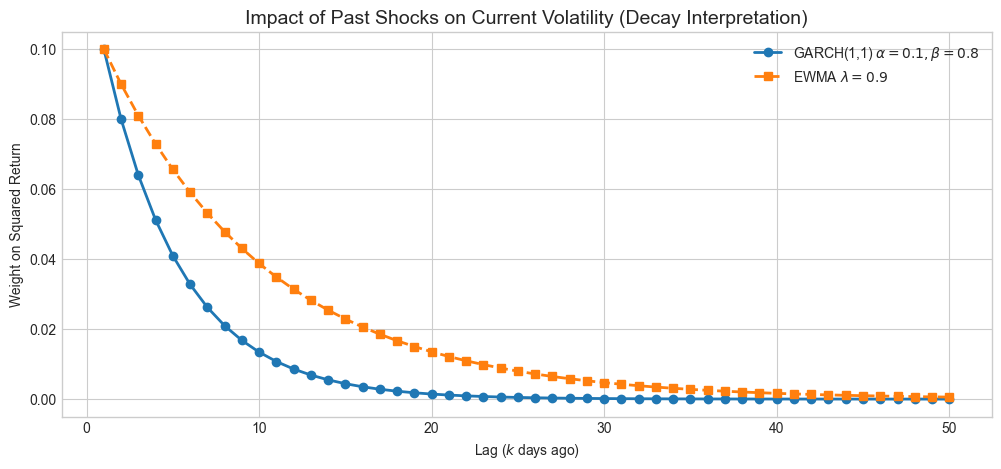

In [3]:
# ============================================================
# 3.3 — VISUALIZATION: GARCH vs EWMA WEIGHTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

def plot_vol_weights(alpha, beta, lambda_ewma, lags=50):
    # GARCH weights roughly decay as alpha * beta^k (simplified approximation for visualization)
    # Actually, GARCH is an infinite ARCH process. The coefficient on epsilon_{t-k}^2 is alpha * beta^(k-1)
    garch_w = [alpha * (beta**(k-1)) for k in range(1, lags+1)]
    
    # EWMA weights: (1-lambda) * lambda^(k-1)
    ewma_w = [(1 - lambda_ewma) * (lambda_ewma**(k-1)) for k in range(1, lags+1)]
    
    garch_label = r'GARCH(1,1) $\alpha=' + str(alpha) + r', \beta=' + str(beta) + r'$'
    ewma_label = r'EWMA $\lambda=' + str(lambda_ewma) + r'$'
    
    plt.figure(figsize=(12, 5))
    plt.plot(range(1, lags+1), garch_w, '-o', label=garch_label, linewidth=2)
    plt.plot(range(1, lags+1), ewma_w, '--s', label=ewma_label, linewidth=2)
    plt.title('Impact of Past Shocks on Current Volatility (Decay Interpretation)', fontsize=14)
    plt.xlabel('Lag ($k$ days ago)')
    plt.ylabel('Weight on Squared Return')
    plt.legend()
    plt.show()

# Typical parameters: Alpha=0.05, Beta=0.90 (persistence 0.95) vs EWMA Lambda=0.94
plot_vol_weights(alpha=0.1, beta=0.80, lambda_ewma=0.9)


**Observation:** Both models decay exponentially, meaning recent events matter most. However, GARCH allows for a flexible decay rate determined by data ($\alpha, \beta$), while EWMA fixes it via $\lambda$. GARCH also includes a baseline variance ($\omega$), unlike EWMA which decays to zero if returns are zero.

---


## 3.4 — Backtesting Framework

Validation asks: **"Is the model accurate?"**
We define a "Hit" sequence $I_t$:
$$ I_t = \begin{cases} 1 & \text{if } r_t < -\text{VaR}_\alpha(t) \\ 0 & \text{otherwise} \end{cases} $$

For a 99% VaR, we expect $I_t = 1$ (exceptions) exactly 1% of the time.

### 1. Kupiec Test (Unconditional Coverage)
Tests if the **proportion** of exceptions matches the expected level ($p$).
- $H_0: p_{obs} = p_{exp}$
- $H_1: p_{obs} \neq p_{exp}$
- Uses a Likelihood Ratio (LR) test: $LR_{uc} \sim \chi^2(1)$.

### 2. Christoffersen Test (Independence)
Tests if exceptions are **clustered**.
- If a model is good, an exception today shouldn't predict an exception tomorrow.
- Checks transition probabilities $P(1|0)$ vs $P(1|1)$.
- $LR_{ind} \sim \chi^2(1)$.

### 3. Basel Traffic Light (Regulatory System)
Basel Committee on Banking Supervision (BCBS) classifies models based on exceptions over the last **250 days** (for 99% VaR).

| Zone | Exceptions (out of 250) | Consequence | Penalty Multiplier ($k$) |
|:---|:---:|:---|:---:|
| **Green** | **0 – 4** | Model Accepted | 3.0 (Min) |
| **Yellow** | **5 – 9** | Review / Monitoring | 3.0 + 0.4 to 3.85 |
| **Red** | **10+** | **Model Rejected** | 4.0 (Max) |


> **Use in Project:** We will categorize our backtesting results into Green/Yellow/Red zones to simulate a real audit report.

> **Penalty Multiplier ($k$)** : If a model is in the Yellow or Red zone, the bank must hold additional capital equal to $k \times \text{VaR}$ to cover potential losses, where $k$ increases with the number of exceptions.

---

### What's Next?
**Section 4: Model Implementation** 
1. Calculate **Historical VaR** (rolling window).
2. Calculate **Parametric VaR** (rolling mean/std).
3. Fit **GARCH(1,1)** models and simulate **Monte Carlo VaR**.
